# Feature-Audit für die Masterarbeit (aFRR, Deutschland)

## Zielsetzung
Dieses Notebook dokumentiert transparent den finalen Feature-Space der ML-Pipeline für den deutschen aFRR-Markt. Im Fokus stehen:

- **Nachvollziehbarkeit** der Feature-Konstruktion,
- **statistische Validierung** (Korrelationen, Multikollinearität),
- **methodische Begründung** für verworfene Variablen.

Damit dient das Notebook als prüfbarer Anhang für die Masterarbeit und als Qualitätssicherung vor dem Modelltraining.


## 1. Setup und Datenbasis
In diesem Abschnitt werden Bibliotheken geladen, ein einheitliches Plot-Design gesetzt und die finale Feature-Datei eingelesen.

**Hinweis zur Robustheit:**
- Das Notebook sucht die Features in mehreren Standardpfaden.
- Bei leicht abweichenden Spaltennamen werden Fallback-Logiken verwendet.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print(f"XGBoost verfügbar: {HAS_XGBOOST}")

XGBoost verfügbar: True


In [2]:
# Robuste Dateisuche (processed -> features)
CANDIDATE_PATHS = [
    Path('../data/processed/all_data_features.parquet'),
    Path('../data/features/all_data_features.parquet'),
]

feature_path = next((p for p in CANDIDATE_PATHS if p.exists()), None)
if feature_path is None:
    raise FileNotFoundError(f'Keine Feature-Datei gefunden. Geprüft: {CANDIDATE_PATHS}')

df = pd.read_parquet(feature_path)
print(f'Geladene Datei: {feature_path}')
print(f'Shape: {df.shape[0]} Zeilen x {df.shape[1]} Spalten')

df.head(3)

Geladene Datei: ../data/features/all_data_features.parquet
Shape: 840 Zeilen x 279 Spalten


,wind_onshore_actual_entsoe,wind_offshore_actual_entsoe,solar_actual_entsoe,wind_onshore_forecast_id_entsoe,wind_offshore_forecast_id_entsoe,solar_forecast_id_entsoe,NRV_balance,afrr_activated_mw_pos,afrr_activated_mw_neg,mfrr_activated_mw_pos,...,target_pos_h72,target_neg_h72,weekday_sin,weekday_cos,is_weekend,is_payday_period,is_morning,is_afternoon,is_evening,is_night
0,29924.8600,6285.7300,2.9500,30156.8450,5542.8800,0.0,184.005,5.907,0.036,0.0,...,736.769920,-999.856904,-2.449294e-16,1.00000,1,1,0,0,0,1
1,30586.2775,5963.4175,2.9225,29461.6725,5262.2350,0.0,809.527,30.213,26.725,0.0,...,709.474568,-1033.966573,7.818315e-01,0.62349,0,1,0,0,0,1
2,29754.0975,5679.2100,3.1325,29029.2475,5108.4325,0.0,542.179,1.957,0.489,0.0,...,709.102029,-1036.617633,7.818315e-01,0.62349,0,1,0,0,0,1


## 2. Feature Dictionary (behaltene Features)
Die Spalten werden in logische Blöcke gruppiert, um den ökonomischen Kontext sichtbar zu machen (z. B. Preise, Fundamentalgrößen, Regelenergie, Zeitmerkmale, Targets).


In [3]:
def categorize_feature(col: str) -> str:
    c = col.lower()
    if c.startswith('target_') or c.startswith('y_true') or c.startswith('y_train'):
        return 'Targets'
    if 'timestamp' in c:
        return 'Zeitstempel/Metadaten'
    if 'price' in c or 'spread' in c or 'vwap' in c:
        return 'Preise & Spreads'
    if 'afrr' in c or 'mfrr' in c or 'nrv' in c or 'picasso' in c:
        return 'Regelenergie & Balancing'
    if 'load' in c or 'residual' in c or 'generation' in c or 'wind' in c or 'solar' in c or 'hydro' in c or 'fossil' in c:
        return 'Fundamentaldaten (Last/Erzeugung)'
    if 'lag' in c or 'mean_' in c or 'std_' in c or 'ewma' in c or 'zscore' in c:
        return 'Lags & Statistikfeatures'
    if 'hour' in c or 'day' in c or 'month' in c or 'holiday' in c or 'regime' in c:
        return 'Zeit- & Regimefeatures'
    return 'Sonstiges'

feature_overview = pd.DataFrame({'feature': df.columns})
feature_overview['kategorie'] = feature_overview['feature'].map(categorize_feature)

summary_by_group = (
    feature_overview.groupby('kategorie', as_index=False)
    .agg(anzahl_features=('feature', 'count'))
    .sort_values('anzahl_features', ascending=False)
)

summary_by_group

,kategorie,anzahl_features
5,Targets,148
2,Preise & Spreads,37
0,Fundamentaldaten (Last/Erzeugung),33
3,Regelenergie & Balancing,28
4,Sonstiges,18
6,Zeit- & Regimefeatures,12
1,Lags & Statistikfeatures,2
7,Zeitstempel/Metadaten,1


In [4]:
# Deskriptive Statistik + Missing-Quote
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

desc = df[numeric_cols].describe().T if numeric_cols else pd.DataFrame()
missing = df.isna().mean().mul(100).rename('missing_pct')

quality_table = (
    pd.DataFrame({'feature': df.columns})
    .merge(missing.reset_index().rename(columns={'index': 'feature'}), on='feature', how='left')
    .merge(feature_overview, on='feature', how='left')
    .sort_values(['missing_pct', 'feature'], ascending=[False, True])
)

print('Top-20 nach Missing-Anteil [%]:')
display(quality_table.head(20))

if not desc.empty:
    print('Deskriptive Statistik (Ausschnitt):')
    display(desc.head(20))

Top-20 nach Missing-Anteil [%]:


,feature,missing_pct,kategorie
6,NRV_balance,0.0,Regelenergie & Balancing
89,TE_hour_regime_activation,0.0,Zeit- & Regimefeatures
8,afrr_activated_mw_neg,0.0,Regelenergie & Balancing
110,afrr_activated_mw_neg_lag1,0.0,Regelenergie & Balancing
111,afrr_activated_mw_neg_lag24,0.0,Regelenergie & Balancing
112,afrr_activated_mw_neg_lag_1h,0.0,Regelenergie & Balancing
113,afrr_activated_mw_neg_lag_24h,0.0,Regelenergie & Balancing
7,afrr_activated_mw_pos,0.0,Regelenergie & Balancing
106,afrr_activated_mw_pos_lag1,0.0,Regelenergie & Balancing
107,afrr_activated_mw_pos_lag24,0.0,Regelenergie & Balancing


Deskriptive Statistik (Ausschnitt):


,count,mean,std,min,25%,50%,75%,max
wind_onshore_actual_entsoe,840.0,22312.277176,11675.292723,2212.092500,12238.455625,21542.705000,32018.885000,45122.492500
wind_offshore_actual_entsoe,840.0,4190.773298,1494.331541,226.712500,3362.898750,4513.110000,5361.129375,6699.345000
solar_actual_entsoe,840.0,1958.669414,4092.356357,2.312500,3.049375,3.960000,2141.853750,27094.870000
wind_onshore_forecast_id_entsoe,840.0,22392.232324,11726.442964,2213.622500,12273.386250,21258.542500,31503.445625,46163.222500
wind_offshore_forecast_id_entsoe,840.0,4115.363723,1462.584678,163.442500,3431.803125,4447.887500,5262.180625,6320.877500
solar_forecast_id_entsoe,840.0,2033.546295,4106.414257,0.000000,0.000000,0.000000,2333.743125,26502.520000
NRV_balance,840.0,109.022144,378.858098,-941.174000,-143.862000,91.503000,342.060750,1942.180000
afrr_activated_mw_pos,840.0,61.284029,110.347997,0.000000,1.118500,17.392000,65.944250,902.017000
afrr_activated_mw_neg,840.0,73.183805,105.331358,0.000000,3.382500,26.861500,100.725250,780.342000
mfrr_activated_mw_pos,840.0,1.799107,22.888919,0.000000,0.000000,0.000000,0.000000,472.000000


## 3. Feature Quality Validation

### 3A. Spearman-Korrelationsanalyse
**Warum relevant?**
Die Spearman-Korrelation misst monotone Zusammenhänge und ist robuster gegenüber Ausreißern als reine Pearson-Korrelation. Für Energiemarktdaten mit Extremphasen (Preisspitzen, Stressstunden) ist das methodisch sinnvoll.


Gewählte Zielspalte: target_pos_h1


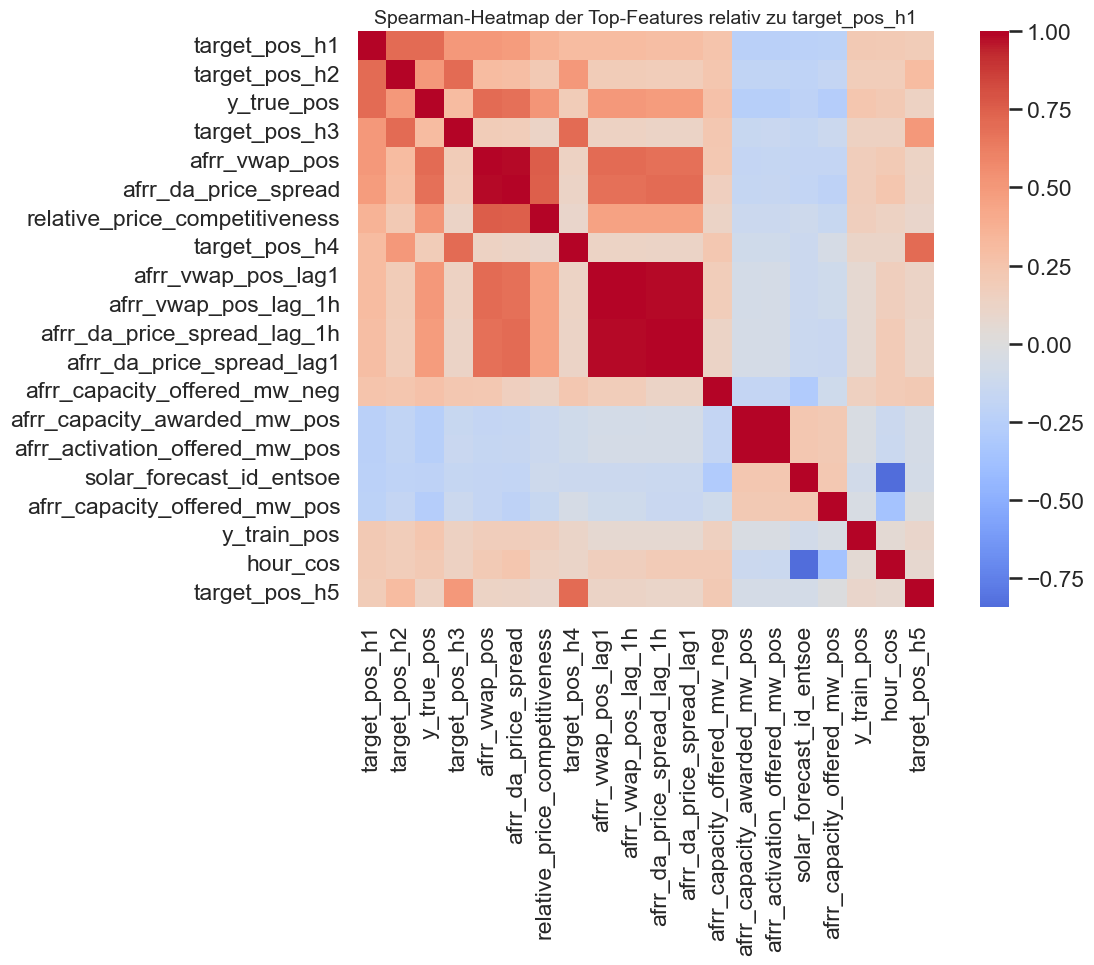

In [5]:
# Zielvariable robust wählen
TARGET_CANDIDATES = [
    'target_pos_h1', 'target_neg_h1',
    'y_true_pos', 'y_true_neg',
]

target_col = next((c for c in TARGET_CANDIDATES if c in df.columns), None)
print('Gewählte Zielspalte:', target_col)

if target_col is None:
    print('Keine Zielspalte gefunden. Korrelationsplot wird übersprungen.')
else:
    corr_df = df.select_dtypes(include=[np.number]).copy()
    if target_col not in corr_df.columns:
        print('Zielspalte ist nicht numerisch. Korrelationsplot wird übersprungen.')
    else:
        # Wähle Top-Features nach absoluter Spearman-Korrelation zum Target
        corr_to_target = corr_df.corr(method='spearman')[target_col].dropna().abs().sort_values(ascending=False)
        top_features = corr_to_target.head(20).index.tolist()

        mat = corr_df[top_features].corr(method='spearman')
        plt.figure(figsize=(13, 10))
        sns.heatmap(mat, cmap='coolwarm', center=0, square=True)
        plt.title(f'Spearman-Heatmap der Top-Features relativ zu {target_col}')
        plt.tight_layout()
        plt.show()

### 3B. Multikollinearitäts-Check (VIF)
**Warum relevant?**
Ein hoher VIF-Wert deutet auf starke lineare Abhängigkeiten hin. Das ist besonders für lineare/regularisierte Modelle (z. B. Lasso, ElasticNet) kritisch, da Koeffizienten instabil werden können.


In [6]:
def compute_vif_table(frame: pd.DataFrame, max_features: int = 40) -> pd.DataFrame:
    num = frame.select_dtypes(include=[np.number]).copy()

    # Targets und offensichtliche Nicht-Feature-Spalten ausschließen
    drop_like = [c for c in num.columns if c.startswith('target_') or c.startswith('y_true') or c.startswith('y_train')]
    num = num.drop(columns=drop_like, errors='ignore')

    # Nur Spalten mit Varianz > 0 und genügend Beobachtungen
    nunique = num.nunique(dropna=True)
    keep = nunique[nunique > 1].index.tolist()
    num = num[keep]

    # Begrenzung für numerische Stabilität/Laufzeit
    if num.shape[1] > max_features:
        # Priorisiere Spalten mit weniger Missingness
        miss = num.isna().mean().sort_values()
        num = num[miss.index[:max_features]]

    # Einfache Imputation (Median) nur für VIF-Berechnung
    num = num.fillna(num.median(numeric_only=True))

    if num.shape[1] < 2:
        return pd.DataFrame(columns=['feature', 'vif'])

    X = num.astype(float).values
    vif_vals = []
    for i, col in enumerate(num.columns):
        try:
            v = variance_inflation_factor(X, i)
        except Exception:
            v = np.nan
        vif_vals.append((col, v))

    return pd.DataFrame(vif_vals, columns=['feature', 'vif']).sort_values('vif', ascending=False)

vif_table = compute_vif_table(df, max_features=40)
print(f'Berechnete VIF-Tabelle für {len(vif_table)} Features')
display(vif_table.head(30))

high_vif = vif_table[vif_table['vif'] > 10]
print(f'Anzahl Features mit VIF > 10: {len(high_vif)}')
if not high_vif.empty:
    display(high_vif)

Berechnete VIF-Tabelle für 40 Features


,feature,vif
38,dayofweek_sin,inf
12,afrr_vwap_neg_lag_24h,inf
34,weekday_sin,inf
28,afrr_activated_mw_pos_lag_1h,inf
27,afrr_activated_mw_pos_lag1,inf
1,afrr_vwap_neg_lag_1h,inf
37,dayofweek_cos,inf
33,weekday_cos,inf
5,afrr_vwap_pos_lag_1h,inf
2,afrr_vwap_neg_lag24,inf


Anzahl Features mit VIF > 10: 32


,feature,vif
38,dayofweek_sin,inf
12,afrr_vwap_neg_lag_24h,inf
34,weekday_sin,inf
28,afrr_activated_mw_pos_lag_1h,inf
27,afrr_activated_mw_pos_lag1,inf
1,afrr_vwap_neg_lag_1h,inf
37,dayofweek_cos,inf
33,weekday_cos,inf
5,afrr_vwap_pos_lag_1h,inf
2,afrr_vwap_neg_lag24,inf


### 3C. Baseline Feature Importance (Modellperspektive)
**Warum relevant?**
Neben statistischen Tests ist es wichtig zu sehen, welche Variablen ein Lernalgorithmus tatsächlich nutzt. Dies erhöht die ökonomische Interpretierbarkeit und unterstützt die Feature-Selektion.


Gewähltes y: target_pos_h1
Entfernte Leakage-Spalten (Anzahl): 153


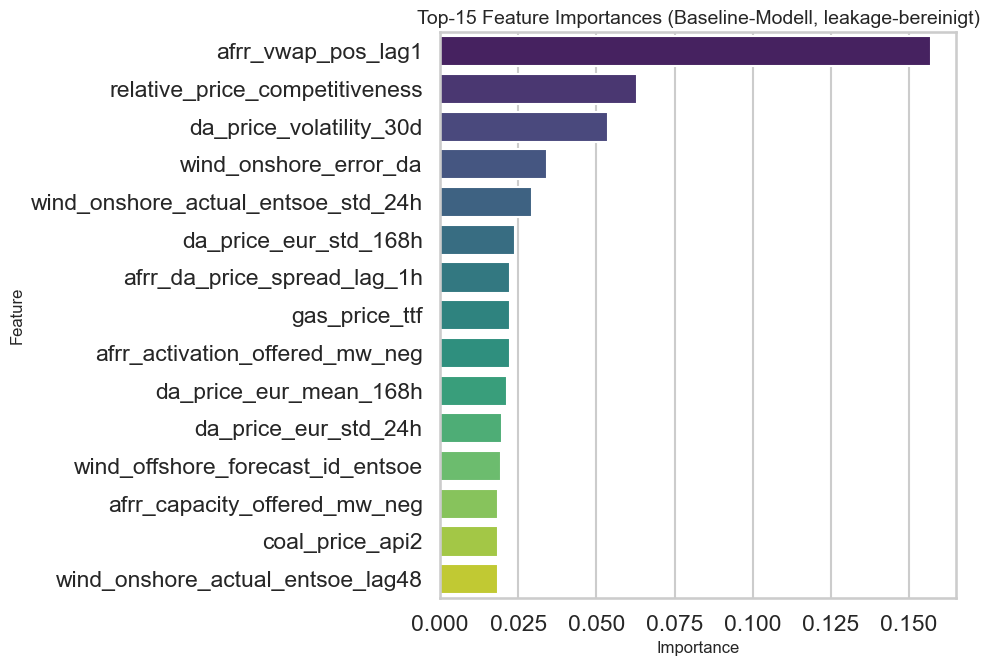

,importance
afrr_vwap_pos_lag1,0.157194
relative_price_competitiveness,0.062977
da_price_volatility_30d,0.053756
wind_onshore_error_da,0.034335
wind_onshore_actual_entsoe_std_24h,0.029258
da_price_eur_std_168h,0.023948
afrr_da_price_spread_lag_1h,0.022451
gas_price_ttf,0.022304
afrr_activation_offered_mw_neg,0.022230
da_price_eur_mean_168h,0.021485


In [7]:
# Baseline-Modell: XGBoost (falls verfügbar), sonst RandomForest
# WICHTIG: Strikter Leakage-Schutz – ungelaggte Targets und deren Transformationen
# werden vollständig aus X entfernt.

TARGET_COLS = [
    'afrr_vwap_pos',
    'afrr_vwap_neg',
    'afrr_activated_mw_pos',
    'afrr_activated_mw_neg',
    'afrr_da_price_spread',
    'afrr_neg_da_price_spread',
    'afrr_activated_mwh_pos',
    'afrr_activated_mwh_neg',
    'target_pos_h1',
    'target_neg_h1',
    'y_true_pos',
    'y_true_neg',
    'y_train_pos',
    'y_train_neg',
]

if target_col is None:
    print('Keine Zielspalte vorhanden; Feature-Importance wird übersprungen.')
else:
    data_num = df.select_dtypes(include=[np.number]).copy()
    if target_col not in data_num.columns:
        print(f'Zielspalte {target_col} ist nicht numerisch/fehlt in data_num.')
    else:
        data_num = data_num.dropna(subset=[target_col])

        # 1) Direkte Zielspalten (nur die vorhandenen)
        present_targets = [c for c in TARGET_COLS if c in data_num.columns]

        # 2) Ziel-Transformationen (log/slog etc.) ebenfalls entfernen
        target_like_patterns = []
        for c in present_targets:
            target_like_patterns.extend([
                c,
                f"{c}_log1p",
                f"{c}_slog1p",
            ])

        # 3) Allgemeine Zielfamilien ausschließen
        leakage_cols = [
            c for c in data_num.columns
            if (
                c in target_like_patterns
                or c.startswith('target_')
                or c.startswith('y_true')
                or c.startswith('y_train')
            )
        ]

        y = data_num[target_col].copy()
        X = data_num.drop(columns=leakage_cols, errors='ignore').copy()

        # Zusätzlicher Guard: das gewählte y darf nie in X liegen.
        if target_col in X.columns:
            X = X.drop(columns=[target_col], errors='ignore')

        print('Gewähltes y:', target_col)
        print('Entfernte Leakage-Spalten (Anzahl):', len(leakage_cols))

        # Robuste, einfache Imputation
        X = X.fillna(X.median(numeric_only=True))

        if len(X) < 50 or X.shape[1] < 3:
            print('Zu wenig Daten/Features für robuste Importance-Schätzung.')
        else:
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

            if HAS_XGBOOST:
                model = XGBRegressor(
                    n_estimators=200,
                    max_depth=4,
                    learning_rate=0.05,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    objective='reg:squarederror',
                    random_state=42,
                )
            else:
                model = RandomForestRegressor(
                    n_estimators=300,
                    max_depth=10,
                    random_state=42,
                    n_jobs=-1,
                )

            model.fit(X_train, y_train)

            if hasattr(model, 'feature_importances_'):
                imp = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
                top15 = imp.head(15)

                plt.figure(figsize=(10, 7))
                sns.barplot(x=top15.values, y=top15.index, orient='h', palette='viridis')
                plt.title('Top-15 Feature Importances (Baseline-Modell, leakage-bereinigt)')
                plt.xlabel('Importance')
                plt.ylabel('Feature')
                plt.tight_layout()
                plt.show()

                display(top15.to_frame('importance'))
            else:
                print('Modell liefert keine direkte feature_importances_-Eigenschaft.')


## 4. Feature Graveyard (verworfene Variablen)
Die folgende Tabelle dokumentiert zentrale Ausschlussentscheidungen. Dies ist methodisch wichtig, um **Leakage-Risiken**, **Multikollinearität** und **fachliche Inkonsistenzen** transparent zu begründen.

| Feature | Grund für Ausschluss | Methodische Einordnung |
|---|---|---|
| `net_import_export_mw` | Physikalisch fehlerhaftes Netting von POS/NEG-Produkten | Durch orthogonale Richtungsspalten ersetzt (`capacity_import_export_mw_pos/neg`) |
| `picasso_flow_rate` (ohne Lag) | Target Leakage: Echtzeitfluss zum Prognosezeitpunkt nicht verfügbar | Ersetzt durch historische Lags (`_lag_1h`, `_lag_24h`) und Regime-Flag |
| `afrr_picasso_net_mw` / `afrr_picasso_churn_mw` | Perfekte lineare Abhängigkeit (VIF = ∞) | Entfernt zur Stabilisierung linearer Modelle |
| `afrr_activated_mw_pos_regelleistung` | Name-Collision / Redundanz mit ähnlichen Aktivierungsgrößen | Nur temporär für Coalesce-Imputation, danach Drop |
| `price_intraday_eur` (ID 4996) | Data-Quality-/Quellenproblem (falsches Land) als ML-Input ungeeignet | Nur ex-post für Profitrechnung als DA-Proxy genutzt |


## 5. Fazit
Die Analyse zeigt einen transparenten, prüfbaren Workflow:

- Feature-Raum ist strukturiert und ökonomisch begründet.
- Potenzielle Redundanzen werden quantitativ (VIF/Korrelation) adressiert.
- Methodisch kritische Variablen sind dokumentiert verworfen.

Damit ist das Feature Engineering sowohl datenwissenschaftlich robust als auch fachlich konsistent für den aFRR-Kontext.
